# Nuclear + BESS Techno-Economic Analysis: LCOE Impact of Adding Battery Storage

Compares combined-system LCOE for two AP1000 units (2400 MW) colocated with a
1000 MW data center, **without** vs **with** a paired BESS (200 MW / 400 MWh,
2-hour duration, 20-80% SOC window), each under no incentive vs. the §48E ITC
(30% of combined CapEx).

**Scope note:** the BESS's role described in the EMT-domain analysis
(Section III) is absorbing sub-second-to-second data center load transients.
This notebook runs at the same hourly resolution as the rest of the H2Integrate
LCOE/NPV analysis in this repo, which cannot represent transients at that
timescale. Consistent with that limitation, the battery's power rating (200 MW)
is treated here as a **fixed input**, set by the peak charging demand
identified in the EMT analysis, rather than something this notebook derives or
validates -- and is unchanged from the single-unit configuration, since it is
fixed by EMT-derived sizing rather than scaled with nuclear or data center
capacity. The 2-hour duration reflects a commercially available utility-scale
battery class, assembled from standardized ~2 MW / 4 MWh units and deployed
at the 100-250 MW scale alongside large AI/industrial loads. This notebook
only answers "what does adding a battery of this size cost," not "does it
actually smooth the transient" -- that claim is supported by the EMT results,
not by this hourly dispatch trace.

**Cost basis:** the battery's `energy_capex` ($355.75/kWh) and `power_capex`
($346.86/kW) in `tech_config.yaml` are sourced directly from NREL's public
ATB 2024 (v4.0.0) electricity database (`ATBe.csv`, Moderate scenario, Market
case), fit against ATB's own published 2/4/6/8/10-hour Overnight Capital Cost
figures (exact fit, R^2 = 1.0). The 2-hour duration used here is one of ATB's
directly published points ($1058.37/kW), so no extrapolation is needed. See
`tech_config.yaml` for full sourcing notes, including why OCC (not ATB's full
"CAPEX" line) is the right basis given what this model already accounts for
elsewhere.


In [1]:
import sys
sys.path.insert(0, "/Users/svijaysh/NPP+DCfork/H2Integrate")

import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from h2integrate.core.h2integrate_model import H2IntegrateModel
from h2integrate.core.file_utils import get_path
from h2integrate.finances.profast_base import ProFastBase
from h2integrate.finances.profast_npv import ProFastNPV

BASELINE_DIR = get_path("examples/32_nuclear_DC_case_1")     # nuclear only, no BESS
BESS_DIR = get_path("examples/32_nuclear_DC_case_5_bess")    # nuclear + BESS

with open(BASELINE_DIR / "plant_config.yaml") as f:
    baseline_plant_config = yaml.safe_load(f)
with open(BESS_DIR / "plant_config.yaml") as f:
    bess_plant_config = yaml.safe_load(f)

NUCLEAR_MW = 2400  # two AP1000 units
NUCLEAR_KW = NUCLEAR_MW * 1000
DC_DEMAND_KW = 1_000_000
ITC_FRACTION = 0.30


def set_itc(plant_config_dict, value_usd):
    """Apply an ITC value to the LCOE finance-group config (works for either
    plant_config, since both share the same finance_parameters structure)."""
    pc = copy.deepcopy(plant_config_dict)
    pc["finance_parameters"]["finance_groups"]["model_inputs"]["params"][
        "one_time_cap_inct"
    ]["value"] = float(value_usd)
    return pc


def set_itc_all(plant_config_dict, value_usd):
    """Apply the same ITC value to both the LCOE and NPV finance-group configs."""
    pc = set_itc(plant_config_dict, value_usd)
    pc["finance_parameters"]["finance_groups"]["npv"]["model_inputs"]["params"][
        "one_time_cap_inct"
    ]["value"] = float(value_usd)
    return pc


def make_baseline_h2i(plant_config_dict):
    config = {
        "name": "nuclear_datacenter_config",
        "system_summary": "Nuclear plant powering a data center (no BESS)",
        "driver_config": str(BASELINE_DIR / "driver_config.yaml"),
        "technology_config": str(BASELINE_DIR / "tech_config.yaml"),
        "plant_config": plant_config_dict,
    }
    model = H2IntegrateModel(config)
    model.setup()
    return model


def run_baseline(model):
    model.prob.set_val("nuclear.system_capacity", NUCLEAR_KW, units="kW")
    model.prob.set_val("grid.interconnection_size", NUCLEAR_KW, units="kW")
    # nuclear_poi is the cost-only interconnection technology (see
    # case_1/tech_config.yaml) that adds nuclear's own POI CapEx/OpEx to the
    # LCOE without pulling in grid buy/sell revenue -- keep it sized to match.
    model.prob.set_val("nuclear_poi.interconnection_size", NUCLEAR_KW, units="kW")
    model.prob.set_val(
        "nuclear.electricity_command_value", np.full(8760, NUCLEAR_KW), units="kW"
    )
    model.prob.set_val(
        "grid.electricity_command_value", np.full(8760, DC_DEMAND_KW), units="kW"
    )
    model.run()


def make_bess_h2i(plant_config_dict):
    config = {
        "name": "nuclear_bess_datacenter_config",
        "system_summary": "Nuclear plant + BESS powering a data center",
        "driver_config": str(BESS_DIR / "driver_config.yaml"),
        "technology_config": str(BESS_DIR / "tech_config.yaml"),
        "plant_config": plant_config_dict,
    }
    model = H2IntegrateModel(config)
    model.setup()
    return model


def run_bess(model):
    model.prob.set_val("nuclear.system_capacity", NUCLEAR_KW, units="kW")
    # nuclear_poi is the cost-only interconnection technology (see
    # case_5_bess/tech_config.yaml) that adds nuclear's own POI CapEx/OpEx to
    # the LCOE without pulling in grid_buy/grid_sell cost/revenue.
    model.prob.set_val("nuclear_poi.interconnection_size", NUCLEAR_KW, units="kW")
    model.prob.set_val(
        "nuclear.electricity_command_value", np.full(8760, NUCLEAR_KW), units="kW"
    )
    model.run()


def shortify(breakdown):
    import re

    out = {}
    for k, v in breakdown.items():
        short = re.sub(r"\s*\([^)]*\)\s*$", "", k.replace("LCOE: ", "")).strip()
        out[short] = v * 1000  # $/kWh -> $/MWh
    # Merge nuclear_poi's interconnection cost into the corresponding
    # nuclear category so it doesn't need its own bar segment in the plots.
    for cat in ("CapEx", "OpEx", "Feedstock"):
        poi_key = f"nuclear_poi {cat}"
        if poi_key in out:
            out[f"nuclear {cat}"] = out.get(f"nuclear {cat}", 0.0) + out.pop(poi_key)
    return out


# -- Monkeypatch: capture the ProFAST object built for the NPV component -------
# H2Integrate/ProFAST don't expose a year-by-year *discounted* cash flow series
# as a public output (only the final scalar NPV). ProFAST does expose the raw
# (undiscounted) cumulative cash flow internally as `pf.cum_cash_flow`, aligned
# to `pf.calendar_year`. We capture that object here so we can discount it
# ourselves, matching Eq.~\ref{eq:combined_npv} in the paper. This is
# validated below: discounting `pf.cum_cash_flow` year-by-year at the
# `discount_rate` input (the cost of equity, Re -- NOT the blended WACC,
# since `cum_cash_flow` already nets out debt service, i.e. it's a
# levered/equity cash flow, which is correctly discounted at Re) reproduces
# ProFAST's own official NPV output exactly.
_captured_pf = {}
if not hasattr(ProFastBase, "_orig_populate_profast_pfcapture"):
    ProFastBase._orig_populate_profast_pfcapture = ProFastBase.populate_profast

    def _populate_profast_capture(self, inputs):
        pf = ProFastBase._orig_populate_profast_pfcapture(self, inputs)
        if isinstance(self, ProFastNPV):
            _captured_pf["pf"] = pf
        return pf

    ProFastBase.populate_profast = _populate_profast_capture


def get_discounted_cum_npv(model, sell_price_mwh, discount_rate):
    """Run `model`'s NPV component at `sell_price_mwh` and return
    (calendar_year, discounted_cumulative_npv_usd), validated to match the
    model's own official NPV_electricity output at the final year."""
    model.prob.set_val(
        "finance_subgroup_nuclear_npv.sell_price_electricity",
        sell_price_mwh / 1000,
        units="USD/(kW*h)",
    )
    model.run()
    official_npv = float(
        model.prob.get_val("finance_subgroup_nuclear_npv.NPV_electricity", "USD")[0]
    )

    pf = _captured_pf["pf"]
    annual_nominal = np.diff(pf.cum_cash_flow, prepend=0.0)
    t = pf.calendar_year - pf.calendar_year[0]
    discounted_cum = np.cumsum(annual_nominal / (1 + discount_rate) ** t)

    assert np.isclose(discounted_cum[-1], official_npv, rtol=1e-6), (
        f"Reconstruction mismatch: {discounted_cum[-1]:.0f} vs official {official_npv:.0f}"
    )
    return pf.calendar_year, discounted_cum


## Combined LCOE Sweep: No BESS vs. With BESS, No Incentive vs. ITC

In [2]:
results_rows = []

# ---- No BESS, no incentive (also gives CapEx to size the ITC credit) ----
m_base_no_itc = make_baseline_h2i(set_itc(baseline_plant_config, 0.0))
run_baseline(m_base_no_itc)
base_capex = float(m_base_no_itc.prob.get_val("nuclear.CapEx", units="USD")[0])
lcoe_base_no_itc = float(
    m_base_no_itc.prob.get_val("finance_subgroup_nuclear.LCOE", units="USD/(kW*h)")[0]
) * 1000
breakdown_base_no_itc = m_base_no_itc.prob.get_val("finance_subgroup_nuclear.LCOE_breakdown")

# ---- No BESS, with ITC ----
itc_usd_base = ITC_FRACTION * base_capex
m_base_itc = make_baseline_h2i(set_itc(baseline_plant_config, itc_usd_base))
run_baseline(m_base_itc)
lcoe_base_itc = float(
    m_base_itc.prob.get_val("finance_subgroup_nuclear.LCOE", units="USD/(kW*h)")[0]
) * 1000
breakdown_base_itc = m_base_itc.prob.get_val("finance_subgroup_nuclear.LCOE_breakdown")

# ---- With BESS, no incentive (also gives combined CapEx to size the ITC credit) ----
m_bess_no_itc = make_bess_h2i(set_itc(bess_plant_config, 0.0))
run_bess(m_bess_no_itc)
bess_capex = float(m_bess_no_itc.prob.get_val("nuclear.CapEx", units="USD")[0]) + float(
    m_bess_no_itc.prob.get_val("battery.CapEx", units="USD")[0]
)
lcoe_bess_no_itc = float(
    m_bess_no_itc.prob.get_val("finance_subgroup_nuclear.LCOE", units="USD/(kW*h)")[0]
) * 1000
breakdown_bess_no_itc = m_bess_no_itc.prob.get_val("finance_subgroup_nuclear.LCOE_breakdown")

# ---- With BESS, with ITC (credit sized to combined nuclear+battery CapEx) ----
itc_usd_bess = ITC_FRACTION * bess_capex
m_bess_itc = make_bess_h2i(set_itc(bess_plant_config, itc_usd_bess))
run_bess(m_bess_itc)
lcoe_bess_itc = float(
    m_bess_itc.prob.get_val("finance_subgroup_nuclear.LCOE", units="USD/(kW*h)")[0]
) * 1000
breakdown_bess_itc = m_bess_itc.prob.get_val("finance_subgroup_nuclear.LCOE_breakdown")

scenarios = [
    ("No BESS", "No incentive", lcoe_base_no_itc, breakdown_base_no_itc),
    ("No BESS", "ITC (30%)", lcoe_base_itc, breakdown_base_itc),
    ("With BESS", "No incentive", lcoe_bess_no_itc, breakdown_bess_no_itc),
    ("With BESS", "ITC (30%)", lcoe_bess_itc, breakdown_bess_itc),
]

for config_label, incentive_label, lcoe, _ in scenarios:
    print(f"{config_label:<10} | {incentive_label:<14} LCOE = ${lcoe:.2f}/MWh")

print(f"\nNuclear-only CapEx:        ${base_capex/1e9:.3f}B")
print(f"Nuclear+battery CapEx:     ${bess_capex/1e9:.3f}B  (+${(bess_capex-base_capex)/1e6:.1f}M for BESS)")

df_breakdowns = {
    (config_label, incentive_label): pd.Series(shortify(breakdown))
    for config_label, incentive_label, _, breakdown in scenarios
}


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


No BESS    | No incentive   LCOE = $135.18/MWh
No BESS    | ITC (30%)      LCOE = $100.03/MWh
With BESS  | No incentive   LCOE = $137.33/MWh
With BESS  | ITC (30%)      LCOE = $101.70/MWh

Nuclear-only CapEx:        $15.450B
Nuclear+battery CapEx:     $15.662B  (+$211.7M for BESS)


## LCOE Breakdown Comparison

Saved: /Users/svijaysh/NPP+DCfork/H2Integrate/examples/32_nuclear_DC_case_5_bess/lcoe_bess_comparison.pdf


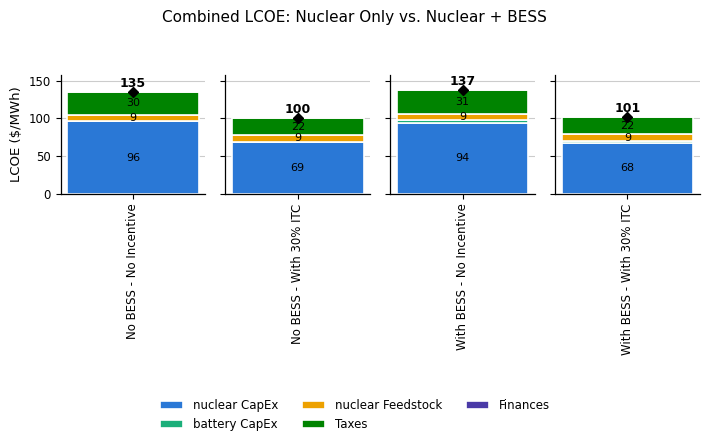

In [3]:
ink = "#000000"
grid_color = "#cccccc"
categories = ["nuclear CapEx", "battery CapEx", "nuclear Feedstock", "Taxes", "Finances"]
colors = {
    "nuclear CapEx": "#2a78d6",     # slot 1 blue
    "battery CapEx": "#1baf7a",     # slot 2 aqua
    "nuclear Feedstock": "#eda100", # slot 3 yellow
    "Taxes": "#008300",             # slot 4 green
    "Finances": "#4a3aa7",          # slot 5 violet
}
LABEL_THRESHOLD = 0.04

panel_order = [
    ("No BESS", "No incentive", "No BESS - No Incentive"),
    ("No BESS", "ITC (30%)", "No BESS - With 30% ITC"),
    ("With BESS", "No incentive", "With BESS - No Incentive"),
    ("With BESS", "ITC (30%)", "With BESS - With 30% ITC"),
]

fig, axes = plt.subplots(1, 4, figsize=(7.2, 4.0), sharey=True)

y_max = max(
    sum(df_breakdowns[key].get(cat, 0.0) for cat in categories) for key in df_breakdowns
)

for ax, (config_label, incentive_label, title) in zip(axes, panel_order):
    s = df_breakdowns[(config_label, incentive_label)]
    bottom = 0.0
    for cat in categories:
        v = float(s.get(cat, 0.0))
        ax.bar(
            0, v, 0.6, bottom=bottom, color=colors[cat],
            edgecolor="white", linewidth=1.2, label=cat,
        )
        if v >= y_max * LABEL_THRESHOLD:
            ax.text(0, bottom + v / 2, f"{v:.0f}", ha="center", va="center",
                     fontsize=8, color=ink)
        bottom += v

    ax.plot(0, bottom, "D", color=ink, ms=5, zorder=5)
    ax.text(0, bottom + y_max * 0.02, f"{bottom:.0f}", ha="center", va="bottom",
             fontsize=9, color=ink, fontweight="bold")

    ax.set_xticks([0])
    ax.set_xticklabels([title], rotation=90, fontsize=8.5, color=ink)
    ax.set_ylim(0, y_max * 1.15)
    ax.grid(axis="y", color=grid_color, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(ink)
    ax.spines["left"].set_color(ink)
    ax.spines["bottom"].set_linewidth(0.9)
    ax.spines["left"].set_linewidth(0.9)
    ax.tick_params(colors=ink, labelsize=8.5, width=0.8)

axes[0].set_ylabel("LCOE ($/MWh)", fontsize=9.5, color=ink)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08),
    frameon=False, fontsize=8.5, labelcolor=ink,
)
fig.suptitle("Combined LCOE: Nuclear Only vs. Nuclear + BESS", fontsize=11, color=ink, y=1.0)
fig.tight_layout(rect=[0, 0.1, 1, 0.95])

out_path = BESS_DIR / "lcoe_bess_comparison.pdf"
fig.savefig(out_path, bbox_inches="tight", pad_inches=0.03, transparent=True)
print(f"Saved: {out_path.resolve()}")
plt.show()


## NPV Over Plant Life: No BESS vs. With BESS, No Incentive vs. ITC

Cumulative discounted NPV as a function of time over the full 80-year
horizon, at a single fixed assumed sell price, for the same four scenarios
used in the LCOE comparison above -- computed per Eq.~\ref{eq:combined_npv},
discounting `pf.cum_cash_flow` year-by-year at the discount rate. Shows when
each scenario turns cash-positive in present-value terms, not just whether
it eventually does.


In [4]:
SELL_PRICE_MWH = 100.0  # reference sell price for the NPV-over-time comparison
DISCOUNT_RATE = bess_plant_config["finance_parameters"]["finance_groups"]["npv"][
    "model_inputs"
]["params"]["discount_rate"]

# ---- No BESS ----
m_base_no_itc_npv = make_baseline_h2i(set_itc_all(baseline_plant_config, 0.0))
run_baseline(m_base_no_itc_npv)
years_base_no_itc, npv_base_no_itc = get_discounted_cum_npv(
    m_base_no_itc_npv, SELL_PRICE_MWH, DISCOUNT_RATE
)

m_base_itc_npv = make_baseline_h2i(set_itc_all(baseline_plant_config, itc_usd_base))
run_baseline(m_base_itc_npv)
years_base_itc, npv_base_itc = get_discounted_cum_npv(
    m_base_itc_npv, SELL_PRICE_MWH, DISCOUNT_RATE
)

# ---- With BESS ----
m_bess_no_itc_npv = make_bess_h2i(set_itc_all(bess_plant_config, 0.0))
run_bess(m_bess_no_itc_npv)
years_bess_no_itc, npv_bess_no_itc = get_discounted_cum_npv(
    m_bess_no_itc_npv, SELL_PRICE_MWH, DISCOUNT_RATE
)

m_bess_itc_npv = make_bess_h2i(set_itc_all(bess_plant_config, itc_usd_bess))
run_bess(m_bess_itc_npv)
years_bess_itc, npv_bess_itc = get_discounted_cum_npv(
    m_bess_itc_npv, SELL_PRICE_MWH, DISCOUNT_RATE
)

npv_time_scenarios = [
    ("No BESS - No Incentive", years_base_no_itc, npv_base_no_itc),
    ("No BESS - With 30% ITC", years_base_itc, npv_base_itc),
    ("With BESS - No Incentive", years_bess_no_itc, npv_bess_no_itc),
    ("With BESS - With 30% ITC", years_bess_itc, npv_bess_itc),
]

print(f"Assumed sell price: ${SELL_PRICE_MWH:.0f}/MWh   (discount rate = {DISCOUNT_RATE:.1%})\n")
for label, years, npv in npv_time_scenarios:
    crossing = years[np.argmax(npv > 0)] if np.any(npv > 0) else None
    crossing_txt = f"breaks even in {crossing}" if crossing else "never breaks even"
    print(f"{label:<28} final NPV = ${npv[-1] / 1e9:+.3f}B   ({crossing_txt})")


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


Assumed sell price: $100/MWh   (discount rate = 12.5%)

No BESS - No Incentive       final NPV = $-2.784B   (never breaks even)
No BESS - With 30% ITC       final NPV = $-0.002B   (never breaks even)
With BESS - No Incentive     final NPV = $-2.954B   (never breaks even)
With BESS - With 30% ITC     final NPV = $-0.134B   (never breaks even)


Saved: /Users/svijaysh/NPP+DCfork/H2Integrate/examples/32_nuclear_DC_case_5_bess/npv_over_time_bess_comparison.pdf


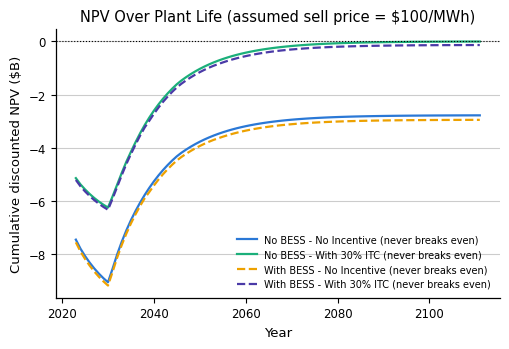

In [5]:
line_colors = {
    "No BESS - No Incentive": "#2a78d6",
    "No BESS - With 30% ITC": "#1baf7a",
    "With BESS - No Incentive": "#eda100",
    "With BESS - With 30% ITC": "#4a3aa7",
}
line_styles = {
    "No BESS - No Incentive": "-",
    "No BESS - With 30% ITC": "-",
    "With BESS - No Incentive": "--",
    "With BESS - With 30% ITC": "--",
}

fig, ax = plt.subplots(figsize=(5.2, 3.6))

for label, years, npv in npv_time_scenarios:
    ax.plot(
        years, npv / 1e9, color=line_colors[label], linestyle=line_styles[label],
        linewidth=1.6, label=label,
    )
    if np.any(npv > 0):
        cross_year = years[np.argmax(npv > 0)]
        ax.plot(cross_year, 0, "o", color=line_colors[label], ms=5, zorder=5,
                 markeredgecolor="white", markeredgewidth=0.8)

ax.axhline(0, color=ink, linewidth=0.8, linestyle=":")
ax.set_xlabel("Year", fontsize=9.5, color=ink)
ax.set_ylabel("Cumulative discounted NPV ($B)", fontsize=9.5, color=ink)
ax.set_title(
    f"NPV Over Plant Life (assumed sell price = ${SELL_PRICE_MWH:.0f}/MWh)",
    fontsize=10.5, color=ink,
)
ax.tick_params(colors=ink, labelsize=8.5)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(ink)
ax.spines["left"].set_color(ink)
ax.spines["bottom"].set_linewidth(0.9)
ax.spines["left"].set_linewidth(0.9)
ax.grid(axis="y", color=grid_color, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

legend_labels = []
for label, years, npv in npv_time_scenarios:
    if np.any(npv > 0):
        cross_year = years[np.argmax(npv > 0)]
        legend_labels.append(f"{label} (breakeven {cross_year})")
    else:
        legend_labels.append(f"{label} (never breaks even)")
ax.legend(legend_labels, fontsize=7, frameon=False, loc="lower right")

fig.tight_layout()
out_path = BESS_DIR / "npv_over_time_bess_comparison.pdf"
fig.savefig(out_path, bbox_inches="tight", pad_inches=0.03, transparent=True)
print(f"Saved: {out_path.resolve()}")
plt.show()


## Breakeven Year vs. Sell Price

Generalizes the single-price NPV-over-time plot above across a range of
assumed sell prices: for each scenario, traces the sell price -> breakeven
year relationship (the (year, price) pairs where discounted cumulative NPV
first crosses zero), so price and time-to-breakeven are shown together in
one plot rather than one price at a time.


In [6]:
BREAKEVEN_SELL_PRICES = [100, 110, 120, 130, 140, 150]


def get_breakeven_year(model, sell_price_mwh, discount_rate):
    """Return the year discounted cumulative NPV first turns positive at
    `sell_price_mwh`, or None if it never does within the plant horizon."""
    years, npv = get_discounted_cum_npv(model, sell_price_mwh, discount_rate)
    if np.any(npv > 0):
        return int(years[np.argmax(npv > 0)])
    return None


breakeven_models = [
    ("No BESS - No Incentive", m_base_no_itc_npv),
    ("No BESS - With 30% ITC", m_base_itc_npv),
    ("With BESS - No Incentive", m_bess_no_itc_npv),
    ("With BESS - With 30% ITC", m_bess_itc_npv),
]

breakeven_curves = {}
for label, model in breakeven_models:
    prices, years = [], []
    for sp in BREAKEVEN_SELL_PRICES:
        by = get_breakeven_year(model, sp, DISCOUNT_RATE)
        if by is not None:
            prices.append(sp)
            years.append(by)
    breakeven_curves[label] = (years, prices)

for label, (years, prices) in breakeven_curves.items():
    if years:
        pairs = ", ".join(f"${p:.0f}->{{{y}}}" for p, y in zip(prices, years))
        print(f"{label:<28} {pairs}")
    else:
        print(f"{label:<28} never breaks even across ${BREAKEVEN_SELL_PRICES[0]:.0f}-{BREAKEVEN_SELL_PRICES[-1]:.0f}/MWh")


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


...

/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


No BESS - No Incentive       $140->{2065}, $150->{2054}
No BESS - With 30% ITC       $110->{2055}, $120->{2048}, $130->{2045}, $140->{2043}, $150->{2041}
With BESS - No Incentive     $140->{2072}, $150->{2056}
With BESS - With 30% ITC     $110->{2057}, $120->{2049}, $130->{2045}, $140->{2043}, $150->{2041}


[sanity check] cheapest scenario (No BESS + ITC) LCOE = $100.03/MWh
Saved: /Users/svijaysh/NPP+DCfork/H2Integrate/examples/32_nuclear_DC_case_5_bess/breakeven_year_vs_price_bess_comparison.pdf


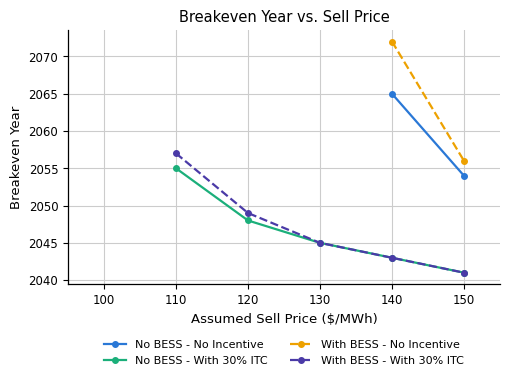

In [7]:
fig, ax = plt.subplots(figsize=(5.2, 4.0))

for label, (years, prices) in breakeven_curves.items():
    if years:
        ax.plot(
            prices, years, color=line_colors[label], linestyle=line_styles[label],
            marker="o", ms=4, linewidth=1.6, label=label,
        )

ax.set_xlabel("Assumed Sell Price ($/MWh)", fontsize=9.5, color=ink)
ax.set_ylabel("Breakeven Year", fontsize=9.5, color=ink)
ax.set_title("Breakeven Year vs. Sell Price", fontsize=10.5, color=ink)
# swept range is $100-150/MWh -- below $100, no scenario (not even the
# cheapest, No BESS + ITC, printed below) reliably breaks even within a few
# years of the horizon, so that region isn't informative to show.
print(f"[sanity check] cheapest scenario (No BESS + ITC) LCOE = ${lcoe_base_itc:.2f}/MWh")
ax.set_xlim(BREAKEVEN_SELL_PRICES[0] - 5, BREAKEVEN_SELL_PRICES[-1] + 5)
ax.set_xticks(BREAKEVEN_SELL_PRICES)
ax.tick_params(colors=ink, labelsize=8.5)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(ink)
ax.spines["left"].set_color(ink)
ax.spines["bottom"].set_linewidth(0.9)
ax.spines["left"].set_linewidth(0.9)
ax.grid(color=grid_color, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Legend below the x-axis, outside the plot, 2 entries per row.
ax.legend(
    fontsize=8, frameon=False, ncol=2, loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
)

fig.tight_layout()
out_path = BESS_DIR / "breakeven_year_vs_price_bess_comparison.pdf"
fig.savefig(out_path, bbox_inches="tight", pad_inches=0.03, transparent=True)
print(f"Saved: {out_path.resolve()}")
plt.show()
